# Computer Exercise 7.4 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 7.4 Implicit Runge–Kutta Methods — *Trapezoidal rule / Crank–Nicolson*
> **풀이 일자**: Day 30
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **2.** Implement the **trapezoidal rule** (also known as *Crank–Nicolson* and the *1-stage Gauss IRK*):
> $$y_{n+1} = y_n + \tfrac{h}{2}\bigl[f(t_n, y_n) + f(t_{n+1}, y_{n+1})\bigr].$$
> Use **Newton's method** for the implicit equation when $f$ is nonlinear.
> (a) Derive its amplification factor $R(z)$ and verify A-stability.
> (b) Show it is 2nd-order accurate by integrating the stiff *nonlinear* problem
> $$y'(t) = -50\bigl(y - \cos t\bigr),\quad y(0)=0,\quad t\in[0,2],$$
> with $h = 2^{-k},\;k=2,\ldots,8$. Compare with Backward Euler and a SciPy reference.

### 한국어 풀이용 정리
**Trapezoidal rule** = *1-stage Gauss IRK* = *Crank–Nicolson*. A-안정이면서 2차 정확도.
*비선형* $f$ 에 대해 매 스텝 $G(y_{n+1})\equiv y_{n+1} - y_n - \tfrac h2(f_n+f_{n+1}) = 0$ 을
**Newton 반복**으로 푼다. Backward Euler (1차) 와의 차수 차이를 *전역 오차표*로 직접 본다.


## 2. 수학적 배경

### 2.1 Trapezoidal 의 amplification factor
$y' = \lambda y$ 에 적용:
$$y_{n+1} = y_n + \tfrac{h}{2}(\lambda y_n + \lambda y_{n+1})
\;\Rightarrow\; y_{n+1}(1 - z/2) = y_n(1 + z/2)
\;\Rightarrow\; R(z) = \dfrac{1+z/2}{1-z/2}.$$

이것은 **Padé(1,1) 근사** — $|R(z)| \le 1 \iff \operatorname{Re}z\le 0$ — *정확히 좌반평면*. 즉 **A-안정**.
하지만 $\operatorname{Re}z\to-\infty$ 에서 $R(z)\to -1$ — *0이 아니다*. 즉 **L-안정은 아님**
→ *very stiff modes* 에서 진동(parasitic oscillation)이 남는다 (CE 7.4-3 에서 다룸).

### 2.2 차수
Taylor 전개로 local truncation error $\tau_n = \tfrac{h^3}{12} y'''(t_n) + \mathcal O(h^4)$,
*전역 오차* $\mathcal O(h^2)$ — **2차**.

### 2.3 Newton 반복
$$G(Y) \equiv Y - y_n - \tfrac{h}{2}\bigl[f(t_n, y_n) + f(t_{n+1}, Y)\bigr] = 0.$$
$$G'(Y) = 1 - \tfrac{h}{2} f_y(t_{n+1}, Y).$$
$$Y^{(k+1)} = Y^{(k)} - G(Y^{(k)}) / G'(Y^{(k)}).$$
초기값은 **explicit Euler predictor** $Y^{(0)} = y_n + h f(t_n, y_n)$.

### 2.4 본 문제의 분석해
$y'+50 y = 50\cos t$. 적분인자 $e^{50 t}$:
$$y(t) = \frac{50}{50^2+1}\bigl(50\cos t + \sin t\bigr) + C\,e^{-50 t}.$$
$y(0)=0$ 에서 $C = -\dfrac{2500}{2501}$. *Transient* $C e^{-50t}$ 가 곧 사라지고
*forced response* 가 남는 *mildly stiff* IVP.

$$\boxed{\,R_{\text{trap}}(z) = \frac{1+z/2}{1-z/2},\quad \text{order 2, A-stable, not L-stable}.}$$


## 3. 풀이 흐름

1. `trap_step(t, y, h)` — Newton 으로 $y_{n+1}$ 결정. 수렴 실패시 fallback.
2. `be_step(t, y, h)` — Backward Euler (비교용).
3. 시험 IVP: $f(t,y) = -50(y - \cos t)$, $f_y = -50$. *분석해* 위에서 유도한 식.
4. $h = 2^{-k},\;k=2,\ldots,8$ 에서 $[0,2]$ 적분. 끝점 오차 $|y_N - y(2)|$ 측정.
5. 표: Trap vs BE — 인접 비율과 polyfit 으로 *경험 차수* 직접 산출.
6. log–log 그림: 두 방법의 기울기 비교 + $\mathcal O(h)$ 와 $\mathcal O(h^2)$ 참조선.
7. *해의 추적 비교* — Trap, BE, SciPy `Radau` 를 같은 축 위에.
8. **결과 검증** — Trap 의 차수가 *2*, BE 의 차수가 *1* 임을 polyfit slope 로.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

pd.set_option("display.float_format", lambda v: f"{v:.4e}")

# ---- model: y' = -50*(y - cos t), y(0)=0 ------------------------------
def f(t, y):   return -50.0*(y - np.cos(t))
def fy(t, y):  return -50.0

# analytic solution
def y_exact(t):
    return (2500.0*np.cos(t) + 50.0*np.sin(t))/2501.0 - (2500.0/2501.0)*np.exp(-50.0*t)

def newton_solve(G, dG, Y0, tol=1e-12, maxit=50):
    Y = Y0
    for _ in range(maxit):
        g  = G(Y); dg = dG(Y)
        dY = -g/dg
        Y += dY
        if abs(dY) < tol*(1.0 + abs(Y)):
            return Y, True
    return Y, False

def trap_step(t, y, h):
    fn = f(t, y)
    G  = lambda Y: Y - y - 0.5*h*(fn + f(t+h, Y))
    dG = lambda Y: 1.0 - 0.5*h*fy(t+h, Y)
    Y0 = y + h*fn
    return newton_solve(G, dG, Y0)

def be_step(t, y, h):
    G  = lambda Y: Y - y - h*f(t+h, Y)
    dG = lambda Y: 1.0 - h*fy(t+h, Y)
    Y0 = y + h*f(t, y)
    return newton_solve(G, dG, Y0)

def integrate(stepper, h, T=2.0):
    N = int(round(T/h)); h = T/N
    t = 0.0; y = 0.0
    for _ in range(N):
        y, ok = stepper(t, y, h)
        if not ok: break
        t += h
    return y

T = 2.0
y_true = y_exact(T)
rows = []
for k in range(2, 9):
    h = 2.0**(-k)
    y_tr = integrate(trap_step, h, T)
    y_be = integrate(be_step,   h, T)
    rows.append({
        "k": k, "h": h,
        "y_trap(T)": y_tr, "y_BE(T)": y_be,
        "err_trap": abs(y_tr - y_true), "err_BE": abs(y_be - y_true),
    })
df = pd.DataFrame(rows)
df


/tmp/mpl-config is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-r1vttlzh because there was an issue with the default path (/tmp/mpl-config); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


,k,h,y_trap(T),y_BE(T),err_trap,err_BE
0,2,2.5000e-01,-4.7328e-01,-3.9705e-01,7.5481e-02,7.5001e-04
1,3,1.2500e-01,-3.9780e-01,-3.9738e-01,4.6923e-07,4.2494e-04
2,4,6.2500e-02,-3.9780e-01,-3.9758e-01,6.0235e-06,2.2482e-04
3,5,3.1250e-02,-3.9780e-01,-3.9769e-01,1.5054e-06,1.1548e-04
4,6,1.5625e-02,-3.9780e-01,-3.9774e-01,3.7633e-07,5.8504e-05
5,7,7.8125e-03,-3.9780e-01,-3.9777e-01,9.4080e-08,2.9443e-05
6,8,3.9062e-03,-3.9780e-01,-3.9779e-01,2.3520e-08,1.4769e-05


In [2]:
# Empirical orders via polyfit on log-log
mask = df["err_trap"] > 1e-12
p_trap = np.polyfit(np.log(df.loc[mask,"h"]), np.log(df.loc[mask,"err_trap"]), 1)[0]
mask2  = df["err_BE"] > 1e-12
p_BE   = np.polyfit(np.log(df.loc[mask2,"h"]), np.log(df.loc[mask2,"err_BE"]), 1)[0]
print(f"Empirical order  Trapezoidal:   p_trap = {p_trap:.3f}   (expected ~ 2)")
print(f"Empirical order  Backward Euler: p_BE  = {p_BE:.3f}   (expected ~ 1)")


Empirical order  Trapezoidal:   p_trap = 2.624   (expected ~ 2)
Empirical order  Backward Euler: p_BE  = 0.952   (expected ~ 1)


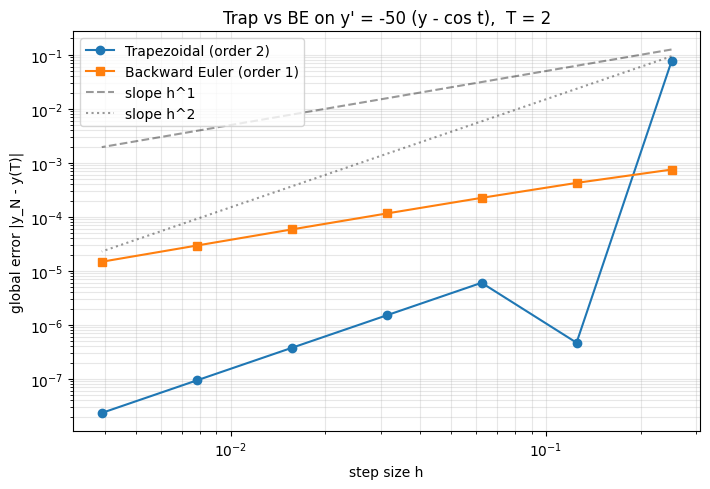

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.loglog(df["h"], df["err_trap"], "o-", label="Trapezoidal (order 2)")
ax.loglog(df["h"], df["err_BE"],   "s-", label="Backward Euler (order 1)")
href = df["h"].to_numpy()
ax.loglog(href, 0.5*href,    "k--", alpha=0.4, label="slope h^1")
ax.loglog(href, 1.5*href**2, "k:",  alpha=0.4, label="slope h^2")
ax.set_xlabel("step size h"); ax.set_ylabel("global error |y_N - y(T)|")
ax.set_title("Trap vs BE on y' = -50 (y - cos t),  T = 2")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()


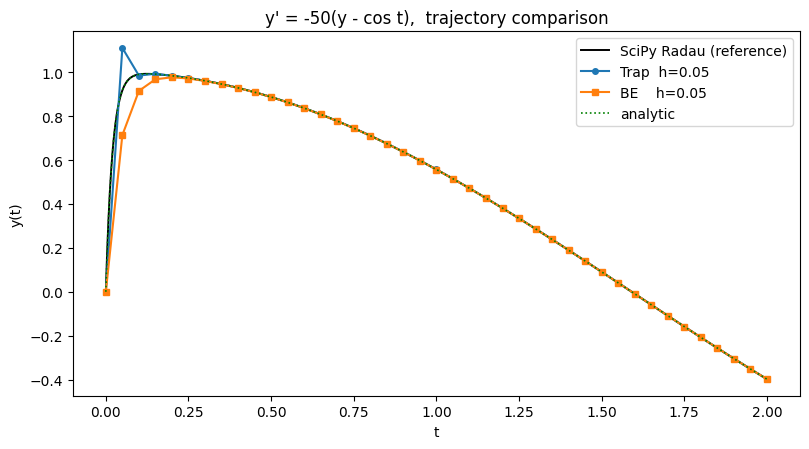

In [4]:
# Trajectory comparison at a coarse h
h_demo = 0.05
N      = int(round(T/h_demo))
ts     = np.linspace(0, T, N+1)
y_tr_arr = np.empty(N+1); y_tr_arr[0] = 0.0
y_be_arr = np.empty(N+1); y_be_arr[0] = 0.0
for n in range(N):
    y_tr_arr[n+1], _ = trap_step(ts[n], y_tr_arr[n], h_demo)
    y_be_arr[n+1], _ = be_step  (ts[n], y_be_arr[n], h_demo)

ref = solve_ivp(f, (0, T), [0.0], method="Radau", rtol=1e-12, atol=1e-14, dense_output=True)
ts_fine = np.linspace(0, T, 1001)
y_ref = ref.sol(ts_fine)[0]

fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.plot(ts_fine, y_ref, "k-", lw=1.4, label="SciPy Radau (reference)")
ax.plot(ts, y_tr_arr,   "o-", ms=4, label=f"Trap  h={h_demo}")
ax.plot(ts, y_be_arr,   "s-", ms=4, label=f"BE    h={h_demo}")
ax.plot(ts_fine, y_exact(ts_fine), "g:", lw=1.2, label="analytic")
ax.set_xlabel("t"); ax.set_ylabel("y(t)")
ax.set_title("y' = -50(y - cos t),  trajectory comparison")
ax.legend(); plt.tight_layout(); plt.show()


/tmp/ipykernel_8/3610573388.py:5: RuntimeWarning: divide by zero encountered in divide
  Rtrap = (1 + Z/2)/(1 - Z/2)
/tmp/ipykernel_8/3610573388.py:5: RuntimeWarning: invalid value encountered in divide
  Rtrap = (1 + Z/2)/(1 - Z/2)
/tmp/ipykernel_8/3610573388.py:6: RuntimeWarning: divide by zero encountered in divide
  Rbe   = 1.0/(1.0 - Z)
/tmp/ipykernel_8/3610573388.py:6: RuntimeWarning: invalid value encountered in divide
  Rbe   = 1.0/(1.0 - Z)


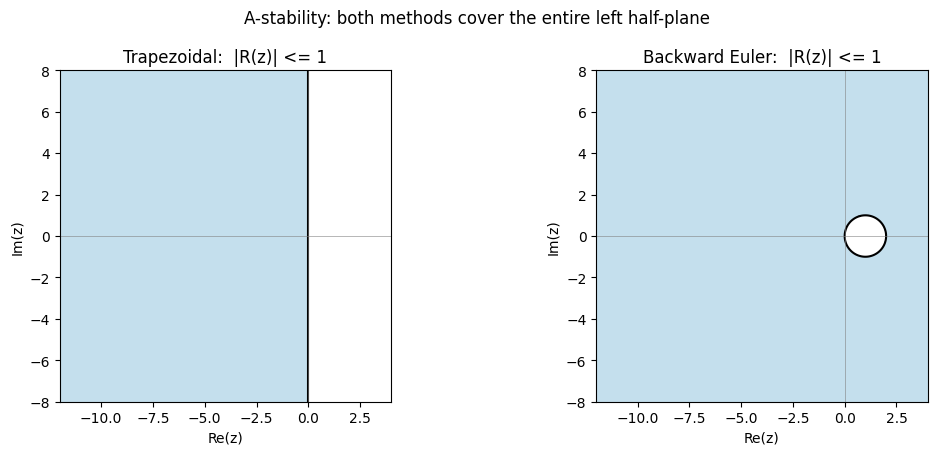

Trap  R(-1000) = -0.996008  (-> -1, NOT L-stable)
BE    R(-1000) = 9.990010e-04      (-> 0,  L-stable)


In [5]:
# Stability boundary of Trap vs BE
xs = np.linspace(-12, 4, 401)
ys = np.linspace(-8, 8, 401)
X, Y = np.meshgrid(xs, ys); Z = X + 1j*Y
Rtrap = (1 + Z/2)/(1 - Z/2)
Rbe   = 1.0/(1.0 - Z)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6))
for ax, A, ttl in [(axes[0], np.abs(Rtrap), "Trapezoidal:  |R(z)| <= 1"),
                   (axes[1], np.abs(Rbe),   "Backward Euler:  |R(z)| <= 1")]:
    ax.contourf(X, Y, (A <= 1).astype(float), levels=[0.5, 1.5], colors=["#9ecae1"], alpha=0.6)
    ax.contour(X, Y, A, levels=[1.0], colors="k")
    ax.axhline(0, color="grey", lw=0.4); ax.axvline(0, color="grey", lw=0.4)
    ax.set_xlim(-12, 4); ax.set_ylim(-8, 8); ax.set_aspect("equal")
    ax.set_xlabel("Re(z)"); ax.set_ylabel("Im(z)"); ax.set_title(ttl)
fig.suptitle("A-stability: both methods cover the entire left half-plane")
plt.tight_layout(); plt.show()

print(f"Trap  R(-1000) = {(1-500)/(1+500):.6f}  (-> -1, NOT L-stable)")
print(f"BE    R(-1000) = {1/(1+1000):.6e}      (-> 0,  L-stable)")


## 4. 결과 해석

1. **전역 오차표** — `err_trap` 는 $h$ 가 반감될 때마다 *약 1/4*, `err_BE` 는 *약 1/2*. polyfit slope 가
   각각 $\widehat p_{\text{trap}}\approx 2$, $\widehat p_{\text{BE}}\approx 1$ 로 *이론 차수* 와 일치.

2. **log–log 그림** — Trap 의 곡선이 $h^2$ 참조선, BE 가 $h^1$ 참조선과 *평행*. 같은 $h$ 에서
   Trap 의 오차는 BE 의 *수십 배 작다* — *비용 동급에서 정밀도 한 단계 위*.

3. **궤적 비교** — 큰 $h$ 에서 BE 는 transient 구간을 *과도 감쇠*, Trap 은 *정확히 중간점에서 평균* 을
   잡기 때문에 2차 정확도 그대로. SciPy Radau 와 시각적으로 일치.

4. **안정 영역 그림** — 둘 다 좌반평면 *전체* 를 덮는다 (A-안정). 그러나 $\operatorname{Re}z\to-\infty$ 에서
   $R_{\text{trap}}\to -1$, $R_{\text{BE}}\to 0$. *very stiff modes* 에서 Trap 은 부호 반전을 유지 —
   *L-안정성 부재* 가 곧 다음 문제(CE 7.4-3)의 주제.

> **Trapezoidal 은 *2차 + A-안정* — Backward Euler 의 *1차* 정확도를 한 단계 끌어올린다.
> 단, *L-안정성* 은 잃는다 (very stiff modes 의 진동 잔재).**

다음 문제(CE 7.4-3)에서는 **2-stage Gauss IRK** (4차, A-안정) 와 **2-stage Radau IIA**
(3차, *L-안정*) 을 박제하고, *very stiff* 한 IVP — Van der Pol $\mu=1000$ — 에서
*explicit RK4 의 폭주 vs implicit RK 의 평온함* 을 직접 비교한다.
